In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

np.random.seed(42)
sns.set_style("whitegrid")

# Task 1: Bias Diagnosis — Case Studies
For each of the following scenarios, identify the type of bias present (selection bias, survivorship bias, measurement bias, response bias, or another relevant type), explain how it distorts the conclusions, and suggest one concrete fix.

Scenario A — App Review Analysis: A product team analyzes their app's reviews on the App Store to understand user satisfaction. The average rating is 4.3/5, so they conclude that most users are happy. They plan to reduce investment in customer support.

Scenario B — Startup Success Study: A business school studies 200 successful tech startups (all founded in the last 10 years and still operating) to identify common traits that predict startup success. They find that 80% had a pivot in their first two years and conclude that pivoting is a key success strategy.

Scenario C — Health Survey: A health organization sends a voluntary online survey to 50,000 email subscribers asking about exercise habits and health outcomes. The survey receives 5,000 responses (10% response rate). Results show that respondents exercise an average of 5 hours per week and have excellent self-reported health.

Scenario D — Salary Benchmarking: A recruiting platform publishes average salaries by job title based on user-submitted salary data. The platform is popular among tech workers in large cities. A company in a small town uses this data to set their salary bands.

Write your analysis in markdown cells — no code required for this task. Aim for 3–5 sentences per scenario.

### Scenario A — App Review Analysis

This scenario shows measurement bias, specifically non-response bias, because only users who choose to leave reviews are included. Users who do not respond may have different experiences, so the collected ratings are not representative. This can lead to overestimating user satisfaction. A fix would be to collect feedback from a broader set of users, such as through in-app surveys.

### Scenario B — Startup Success Study

This is an example of survivorship bias, because the study only looks at startups that are still successful and ignores those that failed. Many failed startups may also have pivoted, but they are not included in the data. This makes it seem like pivoting leads to success, even if it does not. The conclusion is therefore misleading. A fix would be to include both successful and failed startups in the analysis.

### Scenario C — Health Survey

This scenario shows measurement bias, specifically non-response bias, because only 10% of the people responded to the survey. Those who choose to respond are more likely to be health-conscious and active, while less healthy individuals may ignore the survey. This causes the collected data to overestimate exercise levels and overall health. As a result, the conclusions are not representative of the full population. A fix would be to improve response rates (e.g., reminders or incentives) or use more representative sampling methods.

### Scenario D — Salary Benchmarking
This scenario shows selection bias, because the salary data comes mainly from tech workers in large cities. This group is not representative of all workers, especially those in smaller towns where salaries are typically lower. As a result, the average salaries are biased upward and do not reflect the local job market. Using this data can lead the company to set unrealistic or inappropriate salary levels. A fix would be to segment the data by location or collect more representative data from similar regions.

# Task 2: Create the Population
Before you can study sampling, you need a known population to sample from.

Generate a synthetic population of 100,000 individuals with the following columns:
age: integers drawn from a realistic distribution (e.g., a clipped normal centered at 40 with SD of 15, range 18–85).
income: correlated with age — use a linear relationship with noise (e.g., income = 1500 * age + normal_noise). Clip to a realistic range (e.g., 15,000–250,000).
satisfaction: a score from 1–10 that depends on income (higher income → slightly higher satisfaction, with plenty of noise).
region: categorical — randomly assign "Urban" (60%), "Suburban" (25%), "Rural" (15%).
Compute and store the true population parameters: mean age, mean income, mean satisfaction, and the proportion in each region.
Display the population summary and a grid of histograms (one per numerical variable).
These population parameters are your ground truth — everything in the following tasks is measured against them.

In [12]:
n = 100000
age = np.random.normal(loc=40, scale=15, size=n).clip(18, 85).astype(int)
noise = np.random.normal(0, 20000, size=n)
income = 1500 * age + noise
income = np.clip(income, 15000, 250000)
satisfaction = 1 + (income / 250000) * 5 + np.random.normal(0, 1.5, size=n)
satisfaction = np.clip(satisfaction, 1, 10)
region = np.random.choice(
    ["Urban", "Suburban", "Rural"],
    size=n,
    p=[0.6, 0.25, 0.15]
)
population = pd.DataFrame({
    "age":age,
    "satisfaction": satisfaction,
    "income": income,
    "region": region
    })

In [14]:
population.head()

,age,satisfaction,income,region
0,47,5.164999,91111.891760,Suburban
1,37,1.506516,32392.904659,Urban
2,49,1.000000,85008.743804,Urban
3,62,1.000000,80615.230837,Urban
4,36,1.435063,47451.943873,Rural


In [28]:
mean_age = population["age"].mean()
mean_income = population["income"].mean()
mean_satisfaction = population["satisfaction"].mean()
region_proportions = population["region"].value_counts(normalize=True)
population_params = {
    "mean_age": f'{mean_age:.2f}',
    "mean_income": f'{mean_income:.2f}',
    "mean_satisfaction": f'{mean_satisfaction:.2f}',
    "region_proportions": region_proportions
}
population_params

{'mean_age': '40.02',
 'mean_income': '60675.27',
 'mean_satisfaction': '2.42',
 'region_proportions': region
 Urban       0.59927
 Suburban    0.25075
 Rural       0.14998
 Name: proportion, dtype: float64}

Population Summary:

                 age   satisfaction         income
count  100000.000000  100000.000000  100000.000000
mean       40.020520       2.416550   60675.269282
std        14.024143       1.302964   27898.682697
min        18.000000       1.000000   15000.000000
25%        29.000000       1.134289   39781.697192
50%        40.000000       2.199981   59568.800970
75%        50.000000       3.287230   79651.923948
max        85.000000       9.429582  181019.499900

Region Distribution:

region
Urban       0.59927
Suburban    0.25075
Rural       0.14998
Name: proportion, dtype: float64


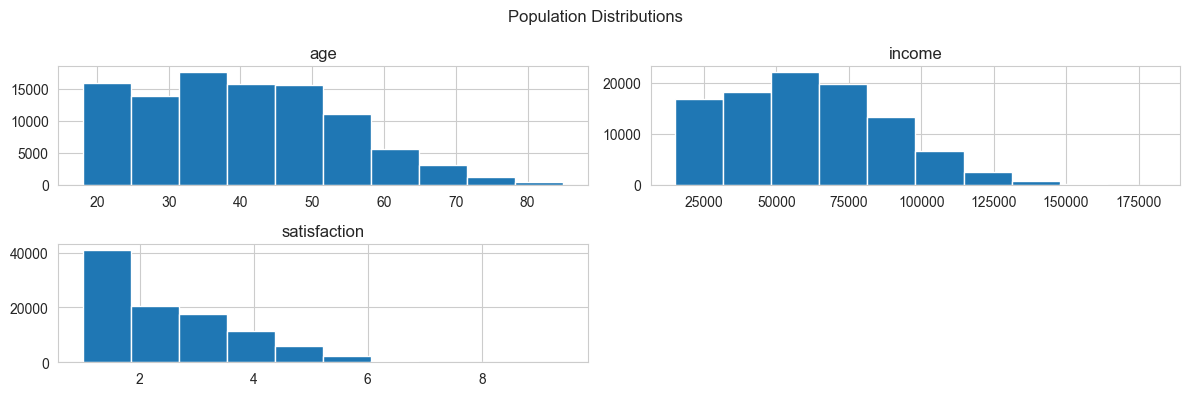

In [34]:
print("Population Summary:\n")
print(population.describe())

print("\nRegion Distribution:\n")
print(population["region"].value_counts(normalize=True))

# --- Histograms ---
population[["age", "income", "satisfaction"]].hist(figsize=(12, 4))
plt.suptitle("Population Distributions")
plt.tight_layout()
plt.show()

# Task 3: Biased vs. Unbiased Sampling
Draw samples from your population using three different strategies and compare how well each recovers the true population parameters.

Simple random sample (n = 200): every individual has an equal chance of being selected.
Biased sample — Urban only (n = 200): only sample from individuals in the "Urban" region.
Biased sample — High-income filter (n = 200): only sample from individuals with income above the population median.
For each sample:

Compute mean age, mean income, and mean satisfaction.
Display the results alongside the true population parameters in a comparison table.
Create overlapping KDE plots (sample vs. population) for income and satisfaction.
Now, repeat each sampling strategy 1,000 times and collect the sample means:

Plot the sampling distribution of the mean income for each strategy (three histograms, side by side).
Mark the true population mean on each histogram.
Guiding question: Which sampling strategies produce biased estimates? How can you tell from the sampling distributions?

In [ ]:
np.random.seed(42)
random_sample = np.random.choice(population, size=200, replace=False)
urban_only = population.loc[population['region']=='Urban']
urban_sample = np.random.choice(urban_only, size=200, replace=False)
high_income = population.loc[population['income'] > population['income'].median()]
income_sample = np.random.choice(high_income, size=200, replace=False)

In [47]:
high_income = population.loc[population['income'] > population['income'].median()]

,age,satisfaction,income,region
0,47,5.164999,91111.891760,Suburban
2,49,1.000000,85008.743804,Urban
3,62,1.000000,80615.230837,Urban
6,63,3.722926,92110.178965,Urban
8,32,2.587004,75636.240423,Urban
...,...,...,...,...
99991,52,1.000000,85663.921771,Rural
99993,43,3.776565,81853.919331,Urban
99994,59,4.367680,76690.232242,Urban
99997,46,1.424551,72200.399275,Suburban


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# --- Simple random sample ---
srs = population.sample(n=200, replace=False)

# --- Urban only sample ---
urban_sample = population[population['region']=='Urban'].sample(n=200, replace=False)

# --- High-income sample ---
high_income_sample = population[population['income'] > population['income'].median()].sample(n=200, replace=False)

# --- Compute sample means ---
def get_means(df):
    return {
        'mean_age': df['age'].mean(),
        'mean_income': df['income'].mean(),
        'mean_satisfaction': df['satisfaction'].mean()
    }

srs_means = get_means(srs)
urban_means = get_means(urban_sample)
high_income_means = get_means(high_income_sample)

# --- Combine into comparison table ---
import pandas as pd

comparison_table = pd.DataFrame({
    'Population': [population['age'].mean(), population['income'].mean(), population['satisfaction'].mean()],
    'SRS': [srs_means['mean_age'], srs_means['mean_income'], srs_means['mean_satisfaction']],
    'Urban Only': [urban_means['mean_age'], urban_means['mean_income'], urban_means['mean_satisfaction']],
    'High-Income': [high_income_means['mean_age'], high_income_means['mean_income'], high_income_means['mean_satisfaction']]
}, index=['Age', 'Income', 'Satisfaction'])

comparison_table

,Population,SRS,Urban Only,High-Income
Age,40.020520,40.290000,40.985000,48.410000
Income,60675.269282,62424.166688,62378.121689,84073.739510
Satisfaction,2.416550,2.416079,2.406445,2.814022


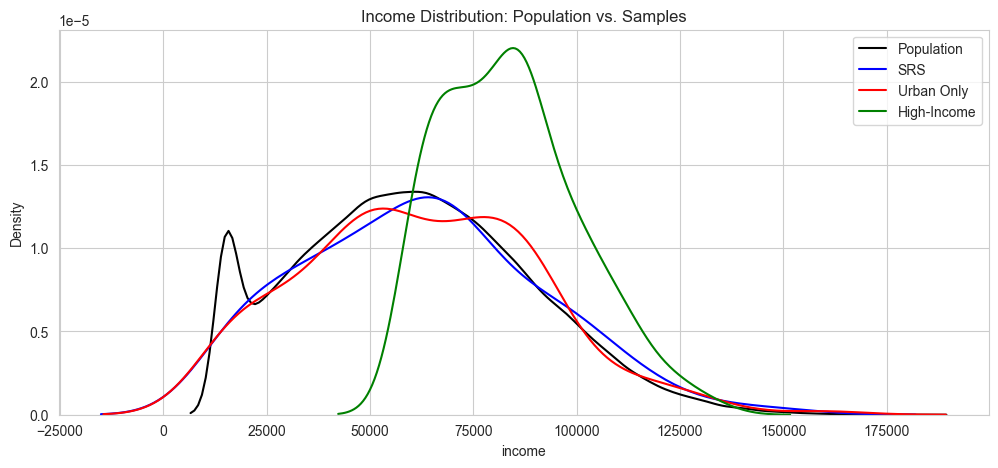

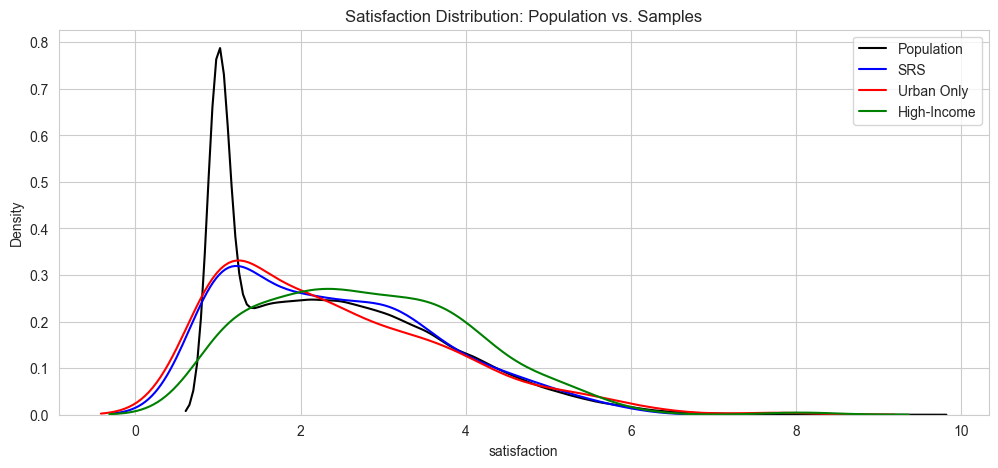

In [51]:
# Income
plt.figure(figsize=(12,5))
sns.kdeplot(population['income'], label='Population', color='black')
sns.kdeplot(srs['income'], label='SRS', color='blue')
sns.kdeplot(urban_sample['income'], label='Urban Only', color='red')
sns.kdeplot(high_income_sample['income'], label='High-Income', color='green')
plt.title('Income Distribution: Population vs. Samples')
plt.legend()
plt.show()

# Satisfaction
plt.figure(figsize=(12,5))
sns.kdeplot(population['satisfaction'], label='Population', color='black')
sns.kdeplot(srs['satisfaction'], label='SRS', color='blue')
sns.kdeplot(urban_sample['satisfaction'], label='Urban Only', color='red')
sns.kdeplot(high_income_sample['satisfaction'], label='High-Income', color='green')
plt.title('Satisfaction Distribution: Population vs. Samples')
plt.legend()
plt.show()

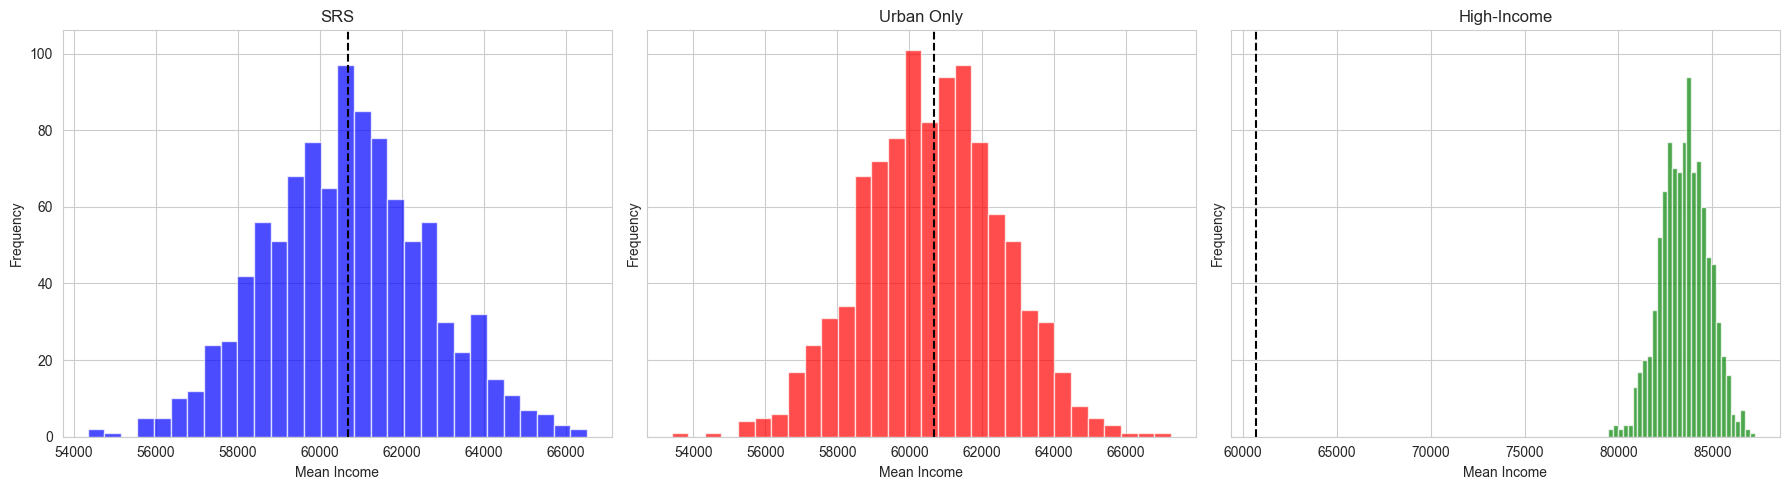

In [53]:
n_sim = 1000
sample_size = 200

srs_means_list = []
urban_means_list = []
high_income_means_list = []

for _ in range(n_sim):
    srs_means_list.append(population.sample(n=sample_size)['income'].mean())
    urban_means_list.append(population[population['region']=='Urban'].sample(n=sample_size)['income'].mean())
    high_income_means_list.append(population[population['income'] > population['income'].median()].sample(n=sample_size)['income'].mean())

# Plot histograms
fig, axes = plt.subplots(1,3, figsize=(18,5), sharey=True)

axes[0].hist(srs_means_list, bins=30, color='blue', alpha=0.7)
axes[0].axvline(population['income'].mean(), color='black', linestyle='--')
axes[0].set_title('SRS')

axes[1].hist(urban_means_list, bins=30, color='red', alpha=0.7)
axes[1].axvline(population['income'].mean(), color='black', linestyle='--')
axes[1].set_title('Urban Only')

axes[2].hist(high_income_means_list, bins=30, color='green', alpha=0.7)
axes[2].axvline(population['income'].mean(), color='black', linestyle='--')
axes[2].set_title('High-Income')

for ax in axes:
    ax.set_xlabel('Mean Income')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()